# 📊 PCA Mini-Project — Finding the Axes Your Data Actually Uses

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **07 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — optional capstone-style notebook (not part of the graded
> assignments). Everything here is assembled from earlier lessons: projections (01),
> linear maps (02), SVD (05), and eigenvectors (06).

---

**Principal Component Analysis** answers a practical question: *given a cloud of correlated
measurements, which directions carry the real information?* The recipe is pure linear
algebra:

1. **Center** the data (subtract the mean).
2. Form the **covariance matrix** $C = \frac{1}{m-1} X^{\mathsf T} X$.
3. Its **eigenvectors** are the principal components — orthogonal axes of maximal variance;
   its **eigenvalues** are the variances along them.
4. **Project** onto the top components to compress with minimal loss.

## Table of contents

1. [Setup](#setup)
2. [A correlated 2-D dataset](#dataset)
3. [The covariance matrix](#covariance)
4. [Principal components via eigendecomposition](#eigen)
5. [Projecting onto PC1 and the reconstruction error](#projection)
6. [Explained variance](#variance)
7. [Scaling up: PCA on a 4-D dataset](#4d)
8. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="dataset"></a>
## 2 · A correlated 2-D dataset

We simulate 200 observations where the second variable is roughly twice the first plus noise
($y \approx 2x + \varepsilon$) — the archetype of *redundant* measurements: two numbers,
but essentially one underlying degree of freedom. After **centering**, the cloud is ready
for PCA (centering matters: covariance is defined around the mean).

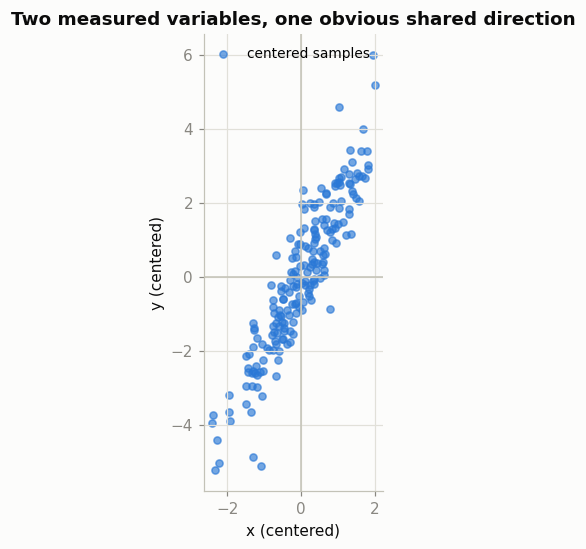

mean removed: [ 0.0153 -0.0403]   (column means now [0. 0.])


In [2]:
rng = np.random.default_rng(0)
m = 200
x_raw = rng.normal(scale=1.0, size=m)
y_raw = 2.0 * x_raw + rng.normal(scale=0.8, size=m)
data = np.column_stack([x_raw, y_raw])

mean = data.mean(axis=0)
X = data - mean                      # centered data matrix (200 × 2)

fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(X[:, 0], X[:, 1], s=22, alpha=0.65, color=PALETTE[0], label="centered samples")
ax.axhline(0, color=BASE, lw=1)
ax.axvline(0, color=BASE, lw=1)
ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_aspect("equal")
ax.set_title("Two measured variables, one obvious shared direction")
ax.legend(fontsize=9)
plt.show()

print(f"mean removed: {mean.round(4)}   (column means now {X.mean(axis=0).round(6)})")

<a id="covariance"></a>
## 3 · The covariance matrix

The sample covariance matrix packs all second-order structure of the cloud:

$$C = \frac{1}{m-1} X^{\mathsf T} X =
\begin{pmatrix} \operatorname{var}(x) & \operatorname{cov}(x,y) \\
\operatorname{cov}(x,y) & \operatorname{var}(y) \end{pmatrix}.$$

The large off-diagonal entry confirms what the scatter shows — $x$ and $y$ move together —
and, being symmetric, $C$ is guaranteed orthogonal eigenvectors (notebook 06).

In [3]:
C = (X.T @ X) / (m - 1)
print("C (from the definition XᵀX/(m−1)) =\n", C)
print("\nnp.cov agrees:", np.allclose(C, np.cov(X, rowvar=False)))
corr = C[0, 1] / np.sqrt(C[0, 0] * C[1, 1])
print(f"correlation coefficient r = {corr:.3f}  (strongly coupled)")

C (from the definition XᵀX/(m−1)) =
 [[0.9285 1.8056]
 [1.8056 4.1845]]

np.cov agrees: True
correlation coefficient r = 0.916  (strongly coupled)


<a id="eigen"></a>
## 4 · Principal components via eigendecomposition

Diagonalizing $C$ yields the **principal components**: orthogonal directions ordered by the
variance they capture. (Equivalently — as seen in notebook 05 — the right singular vectors of
$X$; we verify the two routes agree.) Overlaying the eigenvectors on the cloud, scaled by
$\sqrt{\lambda_i}$ (one standard deviation), shows PCA literally *finds the axes of the
data's ellipse*.

eigenvalues of C      : [4.9876 0.1253]
σ²/(m−1) from SVD of X: [4.9876 0.1253]  ← same numbers
PC1: [0.4064 0.9137]   PC2: [-0.9137  0.4064]
orthogonal? True


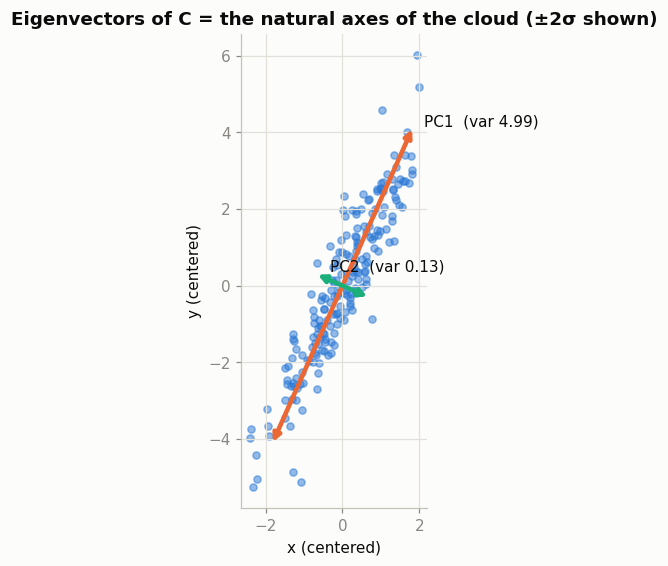

In [4]:
lam, W = np.linalg.eigh(C)                 # eigh: symmetric-aware, ascending order
order = np.argsort(lam)[::-1]              # sort descending by variance
lam, W = lam[order], W[:, order]
pc1, pc2 = W[:, 0], W[:, 1]

# Cross-check against the SVD of the centered data matrix.
_, s_vals, VT = np.linalg.svd(X, full_matrices=False)
print("eigenvalues of C      :", lam.round(4))
print("σ²/(m−1) from SVD of X:", (s_vals**2 / (m - 1)).round(4), " ← same numbers")
print("PC1:", pc1.round(4), "  PC2:", pc2.round(4))
print("orthogonal?", np.isclose(pc1 @ pc2, 0.0))

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.scatter(X[:, 0], X[:, 1], s=22, alpha=0.5, color=PALETTE[0])
for k, (v, colr) in enumerate(zip([pc1, pc2], [PALETTE[1], PALETTE[2]])):
    tip = 2 * np.sqrt(lam[k]) * v          # 2 standard deviations for visibility
    ax.annotate("", xy=tuple(tip), xytext=tuple(-tip),
                arrowprops=dict(arrowstyle="<|-|>", color=colr, lw=3, shrinkA=0, shrinkB=0))
    ax.annotate(f"PC{k+1}  (var {lam[k]:.2f})", xy=tuple(tip), xytext=(8, 2),
                textcoords="offset points", color=INK, fontsize=10)
ax.set_aspect("equal")
ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_title("Eigenvectors of C = the natural axes of the cloud (±2σ shown)")
plt.show()

<a id="projection"></a>
## 5 · Projecting onto PC1 and the reconstruction error

Compressing to one dimension = **projecting every point onto the PC1 line** (the shadow
construction of notebook 01, applied 200 times at once):

$$\text{score}_i = \mathbf{x}_i \cdot \mathbf{w}_1, \qquad
\hat{\mathbf{x}}_i = \text{score}_i\, \mathbf{w}_1 .$$

Among *all* possible lines, PC1 minimizes the total squared residual (the gray whiskers) —
PCA is least squares without a designated "output" variable.

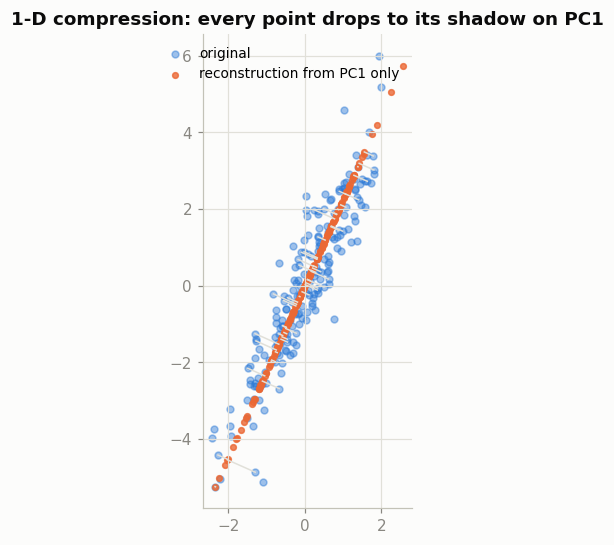

relative reconstruction error with 1 of 2 dimensions: 15.7%
(equals √(λ₂/(λ₁+λ₂)) = 15.7% — the discarded variance)


In [5]:
scores = X @ pc1                     # 1-D representation (200 numbers instead of 400)
X_hat = np.outer(scores, pc1)        # back to 2-D: the reconstruction

fig, ax = plt.subplots(figsize=(6.2, 5.6))
for xi, ri in zip(X[::4], X_hat[::4]):                      # a sample of whiskers
    ax.plot([xi[0], ri[0]], [xi[1], ri[1]], color=GRID, lw=1)
ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.45, color=PALETTE[0], label="original")
ax.scatter(X_hat[:, 0], X_hat[:, 1], s=14, alpha=0.8, color=PALETTE[1],
           label="reconstruction from PC1 only")
ax.set_aspect("equal")
ax.set_title("1-D compression: every point drops to its shadow on PC1")
ax.legend(fontsize=9)
plt.show()

rec_err = np.linalg.norm(X - X_hat) / np.linalg.norm(X)
print(f"relative reconstruction error with 1 of 2 dimensions: {rec_err:.1%}")
print(f"(equals √(λ₂/(λ₁+λ₂)) = {np.sqrt(lam[1] / lam.sum()):.1%} — the discarded variance)")

<a id="variance"></a>
## 6 · Explained variance

The standard PCA report: what fraction of total variance does each component carry?
$\text{explained}_k = \lambda_k / \sum_i \lambda_i$. Here PC1 alone tells ~95% of the
story — the honest summary of a cloud that *looks* 2-D but *is* nearly 1-D.

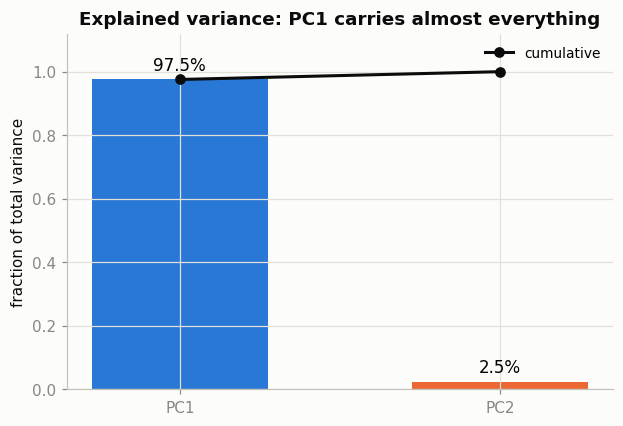

In [6]:
explained = lam / lam.sum()
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
bars = ax.bar([1, 2], explained, width=0.55, color=[PALETTE[0], PALETTE[1]])
ax.plot([1, 2], cumulative, marker="o", ms=6, lw=2, color=INK, label="cumulative")
for xi, e in zip([1, 2], explained):
    ax.annotate(f"{e:.1%}", xy=(xi, e), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=11)
ax.set_xticks([1, 2], ["PC1", "PC2"])
ax.set_ylim(0, 1.12)
ax.set_ylabel("fraction of total variance")
ax.set_title("Explained variance: PC1 carries almost everything")
ax.legend(fontsize=9)
plt.show()

<a id="4d"></a>
## 7 · Scaling up: PCA on a 4-D dataset

Real datasets have more columns than we can plot. The machinery is *identical* in any
dimension. We simulate four correlated sensor channels driven by **two** hidden factors plus
noise, run the same recipe, and let the explained-variance plot ("scree plot") reveal the
true dimensionality — then look at the data in its top-2 PC coordinates.

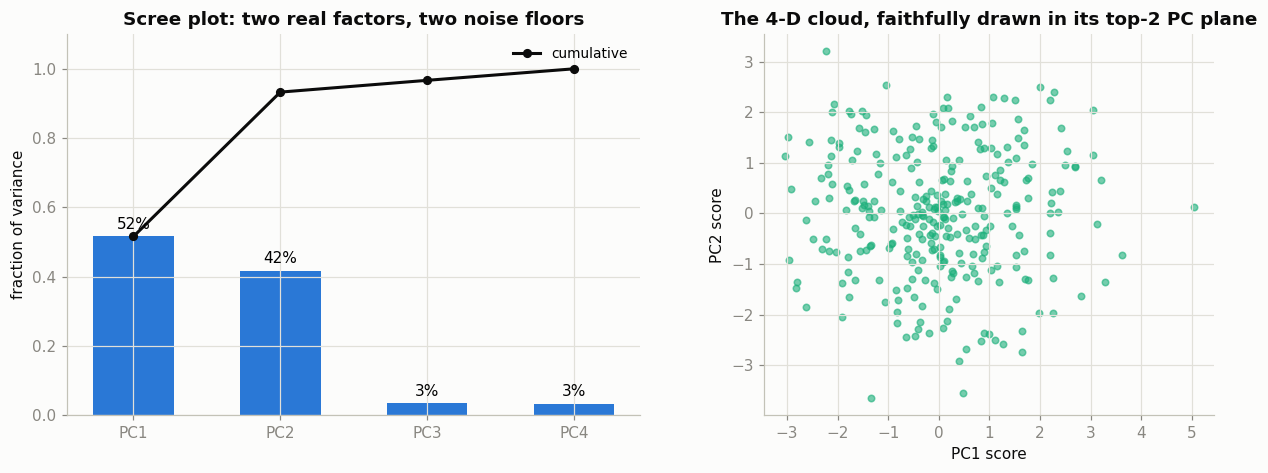

PC1+PC2 explain 93.3% of the variance — matching the 2 hidden factors we built in.


In [7]:
rng = np.random.default_rng(7)
m4 = 300
f1 = rng.normal(size=m4)                      # hidden factor 1
f2 = rng.normal(size=m4)                      # hidden factor 2
noise = rng.normal(scale=0.35, size=(m4, 4))
data4 = np.column_stack([
    1.0 * f1 + 0.5 * f2,
    0.8 * f1 - 0.3 * f2,
    -0.6 * f1 + 0.9 * f2,
    0.4 * f1 + 0.7 * f2,
]) + noise

X4 = data4 - data4.mean(axis=0)
C4 = (X4.T @ X4) / (m4 - 1)
lam4, W4 = np.linalg.eigh(C4)
order = np.argsort(lam4)[::-1]
lam4, W4 = lam4[order], W4[:, order]
explained4 = lam4 / lam4.sum()

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.bar(range(1, 5), explained4, width=0.55, color=PALETTE[0])
ax.plot(range(1, 5), np.cumsum(explained4), marker="o", ms=5, lw=2, color=INK,
        label="cumulative")
for xi, e in zip(range(1, 5), explained4):
    ax.annotate(f"{e:.0%}", xy=(xi, e), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=10)
ax.set_xticks(range(1, 5), [f"PC{k}" for k in range(1, 5)])
ax.set_ylim(0, 1.1)
ax.set_ylabel("fraction of variance")
ax.set_title("Scree plot: two real factors, two noise floors")
ax.legend(fontsize=9)

scores4 = X4 @ W4[:, :2]                       # project 4-D → 2-D
ax = axes[1]
ax.scatter(scores4[:, 0], scores4[:, 1], s=18, alpha=0.6, color=PALETTE[2])
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
ax.set_aspect("equal")
ax.set_title("The 4-D cloud, faithfully drawn in its top-2 PC plane")
plt.tight_layout()
plt.show()

print(f"PC1+PC2 explain {np.cumsum(explained4)[1]:.1%} of the variance — "
      "matching the 2 hidden factors we built in.")

<a id="takeaways"></a>
## 8 · Key takeaways

- PCA = **eigendecomposition of the covariance matrix** of centered data (equivalently the
  SVD of the data matrix — same axes, better numerics for large problems).
- Principal components are the **orthogonal directions of maximal variance**; eigenvalues
  are the variances along them.
- Projecting onto the top-$r$ components gives the **best rank-$r$ compression** of the
  cloud; the discarded eigenvalues *are* the reconstruction error.
- The **scree / explained-variance plot** is the honest dimensionality report: our "4-D"
  sensors were really a 2-factor system.
- Every ingredient was already on the table: shadows (01), maps (02), SVD (05),
  eigenvectors (06). PCA is linear algebra earning its keep.

**Next:** [08 — Interactive linear maps](08_interactive_linear_maps.ipynb): a playground to
drive rotations and scalings by hand.